In [2]:
import pickle
import pandas as pd
import shap


In [29]:
ridge_model = pickle.load(open('data/ridge_model_smote.pkl', 'rb'))
test_file="data/RNAseq_Combat_z_score_Test_set.csv"
annot = pd.read_pickle("data/annot.pkl")
selected_genes_file = "data/selected_genes.txt"
with open(selected_genes_file, "r") as file:
    symbol_names = file.read().splitlines()


/home/karen/Documents/GitHub/shinny/.venv/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.4.1.post1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
test_data = pd.read_csv(test_file)


In [5]:
sample_data = test_data[test_data.columns[-5:]]
sample_data.to_csv("data/test_sample_data.csv", index=False)

In [6]:
sample_data

,Status,Experiment,Age.1,Sample,Sex
0,Healthy,GSE157585,24.0,SRR12604218,NaN
1,Healthy,GSE167186,18.0,SRR13759023,NaN
2,Healthy,GSE167186,23.0,SRR13759025,NaN
3,untrained,GSE60590,26.4,SRR1555206,female
4,Healthy,GSE157585,71.0,SRR12604184,NaN
...,...,...,...,...,...
103,Healthy,GSE157585,71.0,SRR12604112,NaN
104,Healthy,GSE167186,23.0,SRR13759011,NaN
105,Healthy,GSE164471,72.0,SRR13388749,male
106,Healthy,GSE157585,71.0,SRR12604127,NaN


In [7]:
test_data = test_data.fillna(0)

In [8]:
test_data.drop(columns=["Age.1"], inplace=True)
X_test_data = test_data[test_data.columns[:-5]]
z_test_data = test_data[test_data.columns[-4:]]
y_test_data = test_data["Age"]
z_test_data = z_test_data["Experiment"]

In [9]:
z_test_data

0      GSE157585
1      GSE167186
2      GSE167186
3       GSE60590
4      GSE157585
         ...    
103    GSE157585
104    GSE167186
105    GSE164471
106    GSE157585
107    GSE167186
Name: Experiment, Length: 108, dtype: object

In [19]:
explainer = shap.Explainer(ridge_model, X_test_data)
shap_values = explainer(X_test_data)

In [20]:
type(shap_values)

shap._explanation.Explanation

In [ ]:
symbol_names

['NT5C2',
 'ALDOA',
 'BLCAP',
 'FEZ2',
 'SLC16A3',
 'STUM',
 'STUM',
 'CA3',
 'STIM1',
 'ACIN1',
 'HNRNPM',
 'TPM3',
 'CALM1',
 'EHMT1',
 'MYL2',
 'RPS24',
 'ENO3',
 'TNNI1',
 'EEF2',
 'HBA2',
 'MB',
 'RPL13A',
 'KL',
 'GPX7',
 'NDUFB4',
 'KL',
 'TAF9B',
 'AK1',
 'GLB1L',
 'ADA',
 'AK1',
 'GLB1L',
 'ADA',
 'ERI3',
 'RNF7',
 'RECQL',
 'CLIC4',
 'AS3MT',
 'CLIC6',
 'MAST1',
 'CLIC4',
 'CCNI',
 'MMP23B',
 'AK1',
 'CLIC4',
 'CUTC',
 'KLRB1',
 'MICU1',
 'PARK7',
 'SBDS',
 'MEIS2',
 'ALDOA',
 'CA3',
 'FEZ2',
 'EIF3C',
 'UBE2H',
 'CALM1']

In [ ]:
# save shap_values to pickle file
#with open('data/shap_values_ridge.pkl', 'wb') as f:
#    pickle.dump(shap_values, f)

In [43]:
with open('data/shap_values_ridge.pkl', 'rb') as f:
    shap_values = pickle.load( f)

In [44]:
len(shap_values.feature_names)

34505

Sample 0/ 108 
 Age: 24.0 
 Experiment: GSE157585


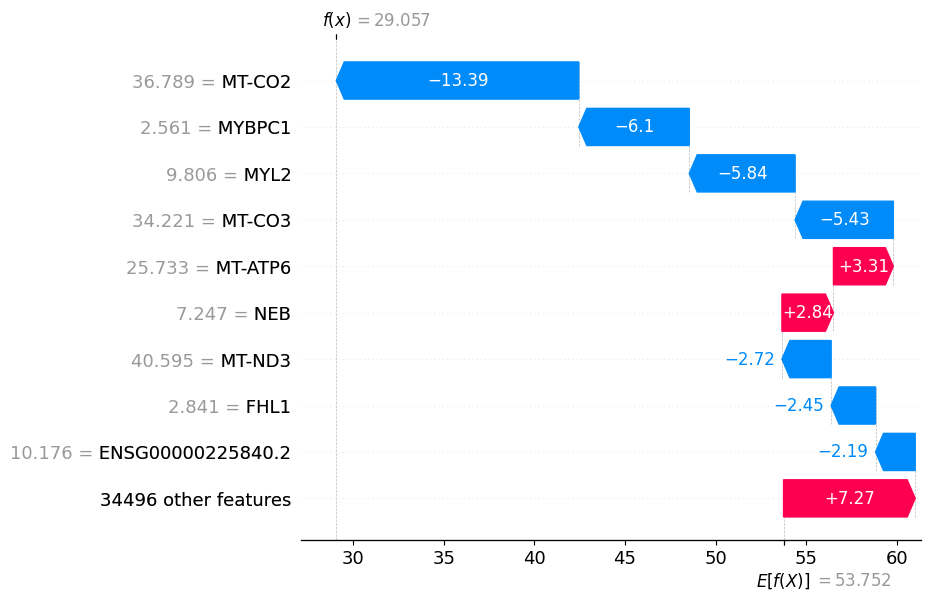

In [45]:
index=0
title = f"Sample {index}/ {len(shap_values)} \n Age: {y_test_data[index]} \n Experiment: {z_test_data[index]}"
print(title)
shap.plots.waterfall(shap_values[index])

In [46]:
import numpy as np

shap_values_at_index = shap_values[index]
shap_values_data = shap_values_at_index.values
feature_names = shap_values.feature_names


In [47]:
len(feature_names)

34505

In [48]:
len(shap_values_data)

34505

In [50]:
from ploting_profiles import get_top_n_shap_values

get_top_n_shap_values(shap_values_at_index=shap_values_at_index, feature_names=feature_names, n=10)

array(['MT-CO2', 'MYBPC1', 'MYL2', 'MT-CO3', 'MT-ATP6', 'NEB', 'MT-ND3',
       'FHL1', 'ENSG00000225840.2', 'ENO3'], dtype='<U18')

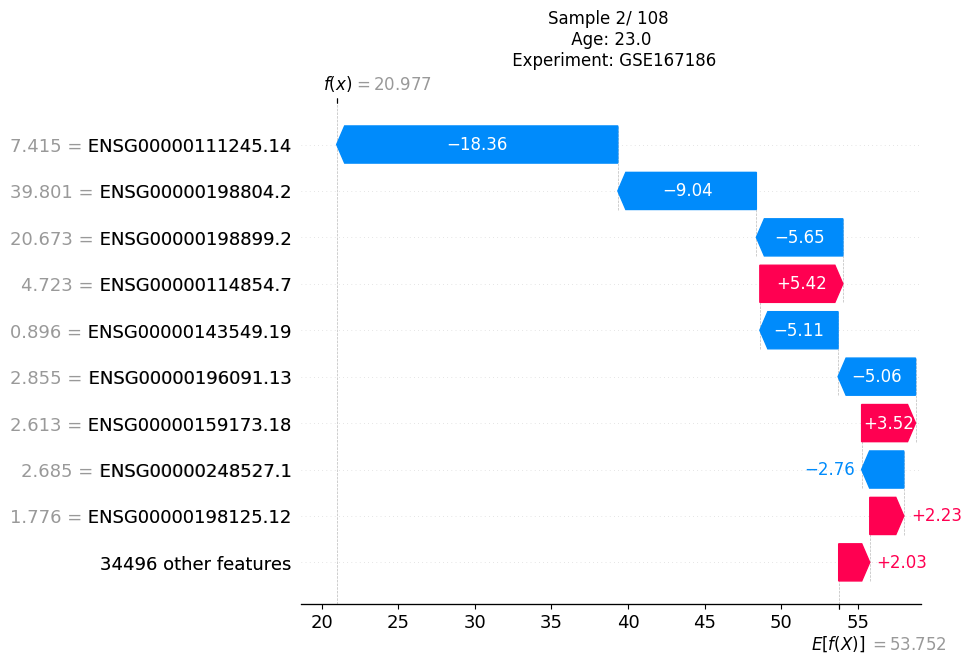

In [9]:
import matplotlib.pyplot as plt


# Create the SHAP waterfall plot
fig = shap.plots.waterfall(shap_values[index], show=False)

# Save the figure
plt.title(title)
plt.savefig(f"shap_waterfall_Ridge_sample_{index}.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()